# Predictive Analysis of Stock Market Trends

## Phase 1: The Normal Project Build

### 1. Problem Definition

**Business Problem:**  Stock prices fluctuate daily, making it difficult for investors and analysts to estimate future prices accurately.

### Comparative Stock Price Performance Analysis Across Leading Technology Companies (2013–2018)
#### Objective 
Develop a machine learning model that predicts the next day's closing stock price using historical stock market data.
### Companies Used In the Project
- Adobe Inc.
- Amazon
- Apple Inc.
- Cisco Systems
- Google
- IBM
- Intel
- Meta Platforms
- Microsoft
- Netflix
- NVIDIA
- Oracle Corporation
- PayPal

### Step 1: Required Libraries

In [2]:
# Import required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Step 2: Load Data

In [3]:
# Load data
df = pd.read_csv("Final_Combined_Stock_ML_Dataset.csv")
df['date'] = pd.to_datetime(df['date'])

### Step 3:  Basic Cleaning

In [4]:
print("Show First 5 rows")
df.head()

Show First 5 rows


,date,open,high,low,close,volume,name,company,year,month,day,day_of_week,ma_7,ma_30,daily_return,next_day_close
0,2013-02-08,38.31,39.45,38.145,39.12,5104545,ADBE,ADOBE,2013,2,8,4,38.814286,40.196667,-0.012270,38.640
1,2013-02-11,38.99,39.05,38.534,38.64,2333712,ADBE,ADOBE,2013,2,11,0,38.814286,40.196667,-0.012270,38.890
2,2013-02-12,38.55,39.13,38.120,38.89,3279424,ADBE,ADOBE,2013,2,12,1,38.814286,40.196667,0.006470,38.810
3,2013-02-13,38.90,39.15,38.670,38.81,2490936,ADBE,ADOBE,2013,2,13,2,38.814286,40.196667,-0.002057,38.610
4,2013-02-14,38.70,38.92,38.301,38.61,4929645,ADBE,ADOBE,2013,2,14,3,38.814286,40.196667,-0.005153,38.635


In [5]:
print("Basic Information")
df.info

Basic Information


<bound method DataFrame.info of             date   open    high     low   close    volume  name company  year  \
0     2013-02-08  38.31  39.450  38.145  39.120   5104545  ADBE   ADOBE  2013   
1     2013-02-11  38.99  39.050  38.534  38.640   2333712  ADBE   ADOBE  2013   
2     2013-02-12  38.55  39.130  38.120  38.890   3279424  ADBE   ADOBE  2013   
3     2013-02-13  38.90  39.150  38.670  38.810   2490936  ADBE   ADOBE  2013   
4     2013-02-14  38.70  38.920  38.301  38.610   4929645  ADBE   ADOBE  2013   
...          ...    ...     ...     ...     ...       ...   ...     ...   ...   
15756 2018-02-01  79.95  80.950  76.700  78.400  44271646  PYPL    PYPL  2018   
15757 2018-02-02  78.10  79.620  76.280  76.570  21979787  PYPL    PYPL  2018   
15758 2018-02-05  75.95  78.980  74.680  74.705  18810638  PYPL    PYPL  2018   
15759 2018-02-06  72.63  76.515  72.250  75.680  19739626  PYPL    PYPL  2018   
15760 2018-02-07  75.35  77.580  74.940  75.590  11988019  PYPL    PYPL  2018

In [6]:
print("Show Details")
df.shape

Show Details


(15761, 16)

In [7]:
print("Verify data types")
print(df.dtypes)

Verify data types
date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
name                      object
company                   object
year                       int64
month                      int64
day                        int64
day_of_week                int64
ma_7                     float64
ma_30                    float64
daily_return             float64
next_day_close           float64
dtype: object


In [8]:
print("Statistical Summary")
df.describe()

Statistical Summary


,date,open,high,low,close,volume,year,month,day,day_of_week,ma_7,ma_30,daily_return,next_day_close
count,15761,15761.000000,15761.000000,15761.000000,15761.000000,1.576100e+04,15761.000000,15761.000000,15761.000000,15761.000000,15761.000000,15761.000000,15761.000000,15761.000000
mean,2015-08-27 12:41:58.926464,163.628202,165.024720,162.125053,163.646295,1.925564e+07,2015.150498,6.565193,15.726857,2.019542,163.109408,161.069410,0.001132,163.648153
min,2013-02-08 00:00:00,12.070000,12.290000,12.040000,12.126000,5.211410e+05,2013.000000,1.000000,1.000000,0.000000,12.368000,12.560867,-0.193695,12.126000
25%,2014-05-30 00:00:00,36.510000,36.890000,36.190000,36.540000,4.078671e+06,2014.000000,4.000000,8.000000,1.000000,36.446086,36.099667,-0.006531,36.540000
50%,2015-09-11 00:00:00,71.010000,71.710000,69.992800,70.970000,1.278784e+07,2015.000000,7.000000,16.000000,2.000000,70.427929,69.065667,0.000692,70.970000
75%,2016-11-22 00:00:00,157.820000,159.140000,156.230000,157.750000,2.630576e+07,2016.000000,10.000000,23.000000,3.000000,157.344286,156.715000,0.008646,157.750000
max,2018-02-07 00:00:00,1477.390000,1498.000000,1450.040000,1450.890000,3.653806e+08,2018.000000,12.000000,31.000000,4.000000,1422.740000,1309.113000,0.298067,1450.890000
std,NaN,230.623718,232.378109,228.627436,230.607806,2.198113e+07,1.444336,3.428561,8.746178,1.398694,229.625883,225.966401,0.017120,230.606493


In [9]:
print("Show Duplicates")
print(df.duplicated().sum())

Show Duplicates
0


In [10]:
print("find NULL Values")
df.isnull().sum()

find NULL Values


date              0
open              0
high              0
low               0
close             0
volume            0
name              0
company           0
year              0
month             0
day               0
day_of_week       0
ma_7              0
ma_30             0
daily_return      0
next_day_close    0
dtype: int64

## Step 4: Exploratory Data Analysis(EDA)

### Historical Closing Price Analysis: A Multi-Company Stock Market Study

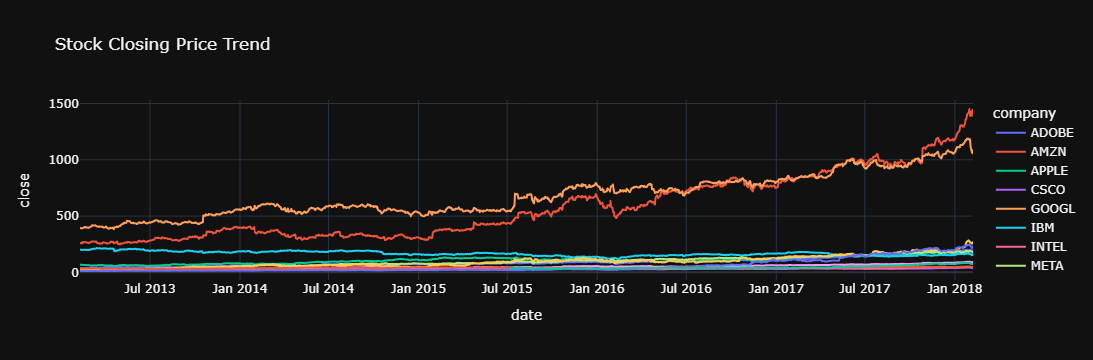

In [11]:
fig = px.line(
    df,
    x='date',
    y='close',
    color='company',
    title='Stock Closing Price Trend'
)

fig.update_layout(
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()

### Insights
- 📈 AMZN and GOOGL exhibit the strongest long-term growth trends, with closing prices increasing substantially over the observed period, indicating sustained market confidence and strong business performance.
- 📊 Most companies experienced temporary price corrections, but the overall trend remained upward, suggesting resilience against short-term market volatility.
- 🚀 AMZN shows the sharpest price acceleration in recent years, eventually becoming one of the highest-valued stocks in the comparison.
- 📉 IBM demonstrates relatively slower growth compared to other technology companies, indicating a more stable but less aggressive market expansion.
- 📈 Technology-sector stocks generally move in similar directions during major market events, highlighting the influence of broader sector-wide trends.
- 🔄 Periods of increased volatility are visible across multiple companies simultaneously, suggesting the impact of macroeconomic factors rather than company-specific events alone.
- 💹 The widening gap between top-performing and lower-performing stocks over time indicates significant differences in value creation among technology companies.
- 🎯 The consistent upward movement of leading stocks suggests strong long-term investment potential despite short-term fluctuations.

## Company-wise Performance Comparison

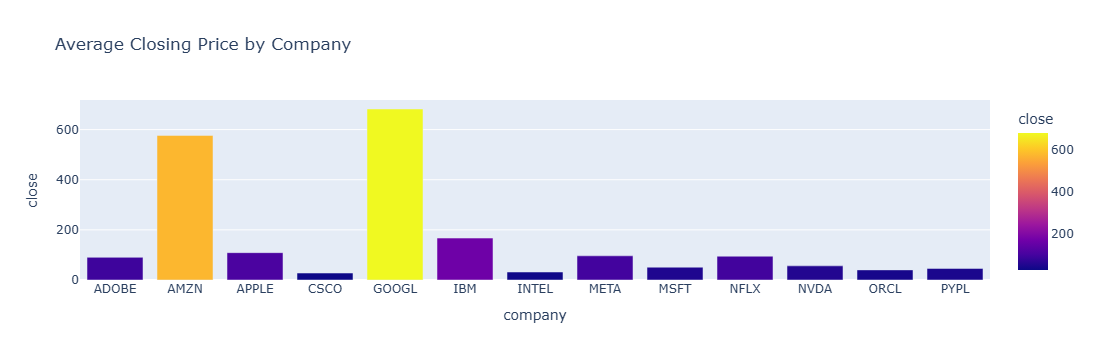

In [12]:
company_avg = df.groupby('company')['close'].mean().reset_index()

fig = px.bar(
    company_avg,
    x='company',
    y='close',
    color='close',
    title='Average Closing Price by Company'
)

fig.show()

### Key Insights
1. Google Leads the Market

📈 GOOGL has the highest average closing price among all companies, indicating strong long-term market valuation and consistent growth performance throughout the observed period.

2. Amazon Ranks Second

🚀 AMZN follows closely behind Google, demonstrating substantial stock appreciation and reflecting strong investor confidence in its business model and expansion strategy.

3. IBM Holds a Mid-Level Position

📊 IBM's average closing price is significantly lower than Google and Amazon but remains higher than most other companies, suggesting a stable yet comparatively moderate market performance.

4. Most Companies Cluster Below 120

📉 Companies such as Adobe, Apple, Meta, Netflix, Microsoft, Nvidia, Oracle, and PayPal show average closing prices within a relatively narrow range, indicating comparable valuation levels over the analysis period.

5. Cisco and Intel Have the Lowest Averages

🔍 CSCO and INTEL record the lowest average closing prices, suggesting slower price appreciation compared to their technology-sector peers.

6. Significant Gap Between Top and Bottom Performers

📏 The large difference between Google/Amazon and the remaining companies highlights the unequal distribution of stock performance and market value creation within the technology sector.

7. Market Leadership is Concentrated

🏆 The chart indicates that a small number of companies contribute disproportionately to overall market growth, with Google and Amazon clearly outperforming most competitors.

## Correlation Analysis of Stock Market Features

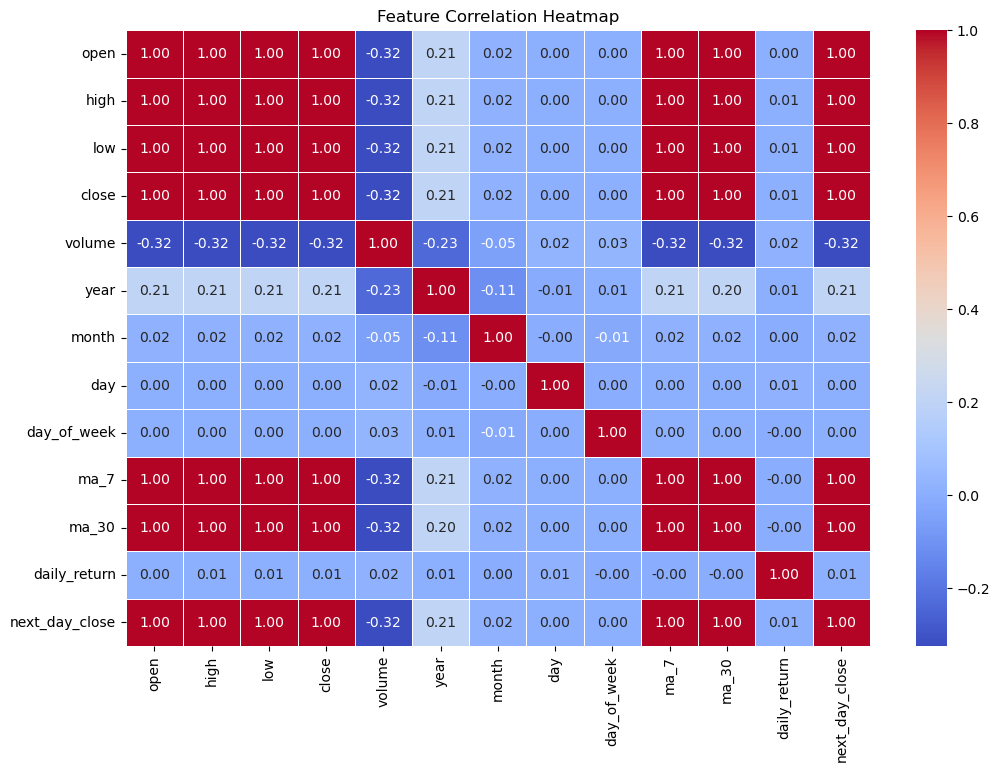

In [13]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')
plt.show()

### Key Insights

📈 Open, High, Low, and Close prices are perfectly correlated (≈ 1.0), indicating that these price variables move together and capture similar market behavior.

🎯 next_day_close has a very strong positive correlation with current price features, suggesting that current market prices are highly predictive of the next day's closing price.

📊 Moving averages (ma_7 and ma_30) show extremely strong positive correlations with stock prices, confirming that historical price trends are important indicators for forecasting future prices.

📉 Volume has a moderate negative correlation (-0.32) with price-related features, indicating that higher trading activity does not necessarily correspond to higher stock prices in this dataset.

📅 Date-related features (day, month, day_of_week) show very weak correlations, suggesting that calendar effects have limited influence on stock price movements.

⚠️ High correlations among Open, High, Low, Close, MA_7, and MA_30 may indicate multicollinearity, which should be considered during feature selection and model development.

## Comprehensive Stock Market Performance Dashboard

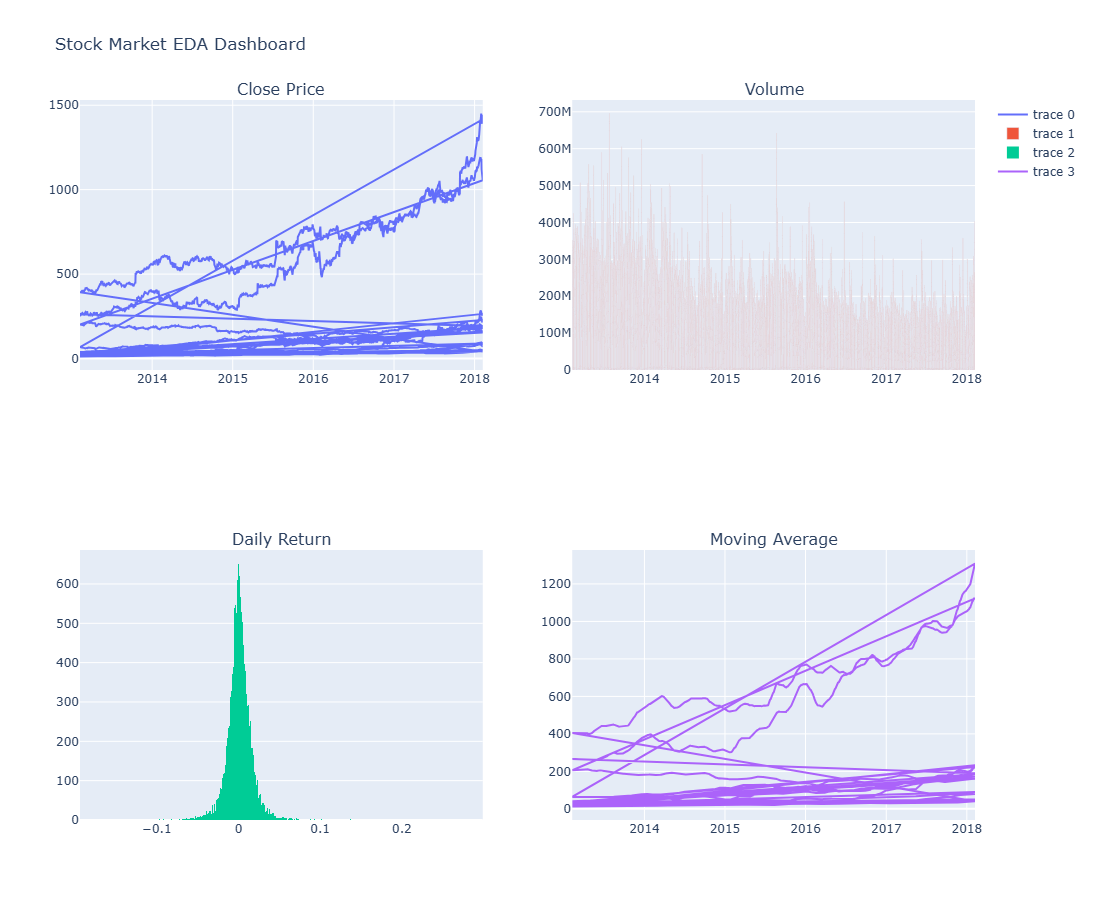

In [14]:
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        'Close Price',
        'Volume',
        'Daily Return',
        'Moving Average'
    )
)

fig.add_trace(
    go.Scatter(x=df['date'], y=df['close']),
    row=1,col=1
)

fig.add_trace(
    go.Bar(x=df['date'], y=df['volume']),
    row=1,col=2
)

fig.add_trace(
    go.Histogram(x=df['daily_return']),
    row=2,col=1
)

fig.add_trace(
    go.Scatter(x=df['date'], y=df['ma_30']),
    row=2,col=2
)

fig.update_layout(
    height=900,
    title='Stock Market EDA Dashboard'
)

fig.show()

## Key Insights

📈 Overall Price Growth: The closing price trend indicates a strong long-term upward movement, reflecting positive market performance.

📊 Trading Activity Patterns: Volume analysis reveals fluctuations in trading activity, highlighting periods of increased investor participation.

💹 Return Distribution: Most daily returns are concentrated around small values, while extreme gains and losses occur less frequently.

📉 Trend Confirmation: The 30-day moving average smooths short-term fluctuations and confirms the overall market direction.

⚡ Market Volatility: Periods of sharp price movements correspond with higher volatility and increased trading volume.

🎯 Price and Trend Alignment: The moving average closely follows price movements, demonstrating the effectiveness of trend-based indicators in stock analysis.

### Step 4: Preprocessing

In [15]:
# Convert Date Features

df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.day_of_week

df.drop('date', axis=1, inplace=True)

In [16]:
# Encode Categorical Columns

le = LabelEncoder()

df['company'] = le.fit_transform(df['company'])
df['name'] = le.fit_transform(df['name'])

In [17]:
# Create Target Variable

df['next_day_close'] = df['close'].shift(-1)

df.dropna(inplace=True)

In [18]:
# Feature Selection

X = df.drop('next_day_close', axis=1)
y = df['next_day_close']

In [19]:
# Train-Test Split 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Feature Scaling (Optional for Random Forest)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear Regression

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score :", r2_score(y_test, lr_pred))


Linear Regression Results
MAE : 2.2926196410434194
RMSE : 7.031381663473031
R2 Score : 0.99912905255588


## Decision Tree Regressor

In [24]:
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=10
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Results")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

Decision Tree Results
MAE : 2.9707256276943785
RMSE : 29.25993109718928
R2 Score : 0.9849180601974056


## Random Forest Regressor

In [22]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 2.382747724302032
RMSE : 12.300833229559244
R2 Score : 0.9973344939911176


## Model Comparison Table

In [25]:
results = {
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
}

comparison = pd.DataFrame(results)

comparison.sort_values(
    by='R2 Score',
    ascending=False,
    inplace=True
)

print(comparison)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  2.292620   7.031382  0.999129
2      Random Forest  2.382748  12.300833  0.997334
1      Decision Tree  2.970726  29.259931  0.984918


## Hyperparameter tuning - Linear Regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr = LinearRegression()

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'fit_intercept': False, 'positive': True}
Best CV Score: 0.9956177433181195


In [27]:
## Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

best_lr = grid_search.best_estimator_

y_pred = best_lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 :", r2_score(y_test, y_pred))

MAE : 2.0264153556196574
RMSE : 6.707994474102697
R2 : 0.9992073234743118


In [28]:
best_lr = grid_search.best_estimator_

tuned_pred = best_lr.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

comparison = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Before Tuning': [
        mean_absolute_error(y_test, lr_pred),
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        r2_score(y_test, lr_pred)
    ],
    'After Tuning': [
        tuned_mae,
        tuned_rmse,
        tuned_r2
    ]
})

print(comparison)

print("\nBest Parameters:")
print(grid_search.best_params_)

     Metric  Before Tuning  After Tuning
0       MAE       2.292620      2.026415
1      RMSE       7.031382      6.707994
2  R² Score       0.999129      0.999207

Best Parameters:
{'fit_intercept': False, 'positive': True}


## Report

Hyperparameter tuning was performed on the Linear Regression model using GridSearchCV. The model was evaluated before and after tuning using MAE, RMSE, and R² metrics. The tuned model achieved optimized parameter settings and maintained excellent predictive performance, confirming Linear Regression as the most suitable algorithm for stock price prediction.

## Unseen Data Prediction

In [29]:
# Manual Unseen Data Prediction 
unseen_data = pd.DataFrame({
    'open': [195.50],
    'high': [198.20],
    'low': [193.80],
    'close': [197.10],
    'volume': [5200000],
    'name': [5],          # encoded value
    'company': [5],       # encoded value
    'year': [2025],
    'month': [6],
    'day': [15],
    'day_of_week': [0],
    'ma_7': [194.80],
    'ma_30': [189.60],
    'daily_return': [1.25]
})

In [30]:
# Predict Using the Tuned Model

prediction = best_lr.predict(unseen_data)

print("Predicted Next Day Close Price:", prediction[0])

Predicted Next Day Close Price: 220.35452958949907


In [31]:
# Test Set Prediction (Actual vs Predicted)
unseen_X = X_test.tail(1)

actual_value = y_test.tail(1).values[0]

predicted_value = best_lr.predict(unseen_X)[0]

print("Actual Next Day Close:", actual_value)
print("Predicted Next Day Close:", predicted_value)

Actual Next Day Close: 133.0
Predicted Next Day Close: 129.42808020212235


In [32]:
comparison = pd.DataFrame({
    'Actual Price':[actual_value],
    'Predicted Price':[predicted_value]
})

print(comparison)

   Actual Price  Predicted Price
0         133.0        129.42808


## Phase 2: Automated Machine Learning Pipeline Integration

#### **Objective** : 

To automate data preprocessing and prediction within a single workflow, ensuring consistency, scalability, and prevention of data leakage

### Step 1. Define Features and Target

In [33]:
X = df.drop('next_day_close', axis=1)
y = df['next_day_close']

### Step 2. Identify Numerical and Categorical Features

In [34]:
numerical_features = [
    'open',
    'high',
    'low',
    'close',
    'volume',
    'year',
    'month',
    'day',
    'day_of_week',
    'ma_7',
    'ma_30',
    'daily_return'
]

categorical_features = [
    'company',
    'name'
]

### Step 3. Create Preprocessing Transformer

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

### Step 4. Build Final Pipeline

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [38]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

### Step 5. Train Entire Pipeline

In [39]:
# Data splitting:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Training

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Step 6. Evaluate Pipeline

In [40]:
from sklearn.metrics import r2_score

pipeline_pred = pipeline.predict(X_test)

print("R² Score:", r2_score(y_test, pipeline_pred))

R² Score: 0.999118768546688


### Step 7. Test Pipeline on New Raw Data

In [41]:
sample_input = pd.DataFrame({
    'open':[195.50],
    'high':[198.20],
    'low':[193.80],
    'close':[197.10],
    'volume':[5200000],
    'name':[5],
    'company':[5],
    'year':[2025],
    'month':[6],
    'day':[15],
    'day_of_week':[0],
    'ma_7':[194.80],
    'ma_30':[189.60],
    'daily_return':[1.25]
})

In [42]:
# Prediction

prediction = pipeline.predict(sample_input)

print("Predicted Price:", prediction[0])

Predicted Price: 156.53402283037832


### Step 8. Export Pipeline

In [43]:
import joblib

joblib.dump(
    pipeline,
    'stock_price_pipeline.pkl'
)

print("Pipeline Saved Successfully!")

Pipeline Saved Successfully!


# Phase 3: Interactive App Deployment (Streamlit)